In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path("../data_sets")
 
train_features_df = pd.read_csv(
    DATA_DIR / "training_set_features.csv"
)

train_labels_df = pd.read_csv(
    DATA_DIR / "training_set_labels.csv"
)

test_features_df = pd.read_csv(
    DATA_DIR / "test_set_features.csv"
)
 

print("Training features:", train_features_df.shape)
print("Training labels:", train_labels_df.shape)
print("Test features:", test_features_df.shape)
 

Training features: (26707, 36)
Training labels: (26707, 3)
Test features: (26708, 36)


In [ ]:
print("Training feature columns:")
print(train_features_df.columns.tolist())

print("\nTraining label columns:")
print(train_labels_df.columns.tolist())

In [2]:
DATA_DIR = Path("../data_sets")

train_features_df = pd.read_csv(DATA_DIR / "training_set_features.csv")
train_labels_df = pd.read_csv(DATA_DIR / "training_set_labels.csv")
test_features_df = pd.read_csv(DATA_DIR / "test_set_features.csv")

print("Training features:", train_features_df.shape)
print("Training labels:", train_labels_df.shape)
print("Test features:", test_features_df.shape)

Training features: (26707, 36)
Training labels: (26707, 3)
Test features: (26708, 36)


In [3]:
TARGETS = ["h1n1_vaccine", "seasonal_vaccine"]

checks = {
    "Feature rows == label rows": len(train_features_df) == len(train_labels_df),
    "Duplicate respondent_id (features)": train_features_df["respondent_id"].duplicated().sum(),
    "Duplicate respondent_id (labels)": train_labels_df["respondent_id"].duplicated().sum(),
    "Duplicate feature rows (ignoring ID)": train_features_df.drop(columns="respondent_id").duplicated().sum(),
    "IDs without a match": len(set(train_features_df["respondent_id"]) ^ set(train_labels_df["respondent_id"])),
    "Missing target values": train_labels_df[TARGETS].isna().sum().sum(),
    "Targets not in {0,1}": (~train_labels_df[TARGETS].isin([0, 1])).sum().sum(),
    "Test columns match train": list(test_features_df.columns) == list(train_features_df.columns),
}
pd.Series(checks, name="result").to_frame()

,result
Feature rows == label rows,True
Duplicate respondent_id (features),0
Duplicate respondent_id (labels),0
Duplicate feature rows (ignoring ID),0
IDs without a match,0
Missing target values,0
"Targets not in {0,1}",0
Test columns match train,True


All integrity checks pass. No duplicates, no unmatched IDs, no missing or invalid targets, so no rows are removed at this stage.

In [4]:
merged_train_data_df = train_features_df.merge(
    train_labels_df, on="respondent_id", how="inner", validate="one_to_one"
)

assert merged_train_data_df.shape == (
    len(train_features_df), train_features_df.shape[1] + len(TARGETS)
)
print("Merged shape:", merged_train_data_df.shape)

Merged shape: (26707, 38)


In [5]:
missing_summary = (
    merged_train_data_df.isna().agg(["sum", "mean"]).T
    .rename(columns={"sum": "missing_count", "mean": "missing_pct"})
    .query("missing_count > 0")
    .assign(missing_pct=lambda d: (d["missing_pct"] * 100).round(1))
    .sort_values("missing_pct", ascending=False)
)
missing_summary

,missing_count,missing_pct
employment_occupation,13470.0,50.4
employment_industry,13330.0,49.9
health_insurance,12274.0,46.0
income_poverty,4423.0,16.6
doctor_recc_seasonal,2160.0,8.1
doctor_recc_h1n1,2160.0,8.1
rent_or_own,2042.0,7.6
employment_status,1463.0,5.5
education,1407.0,5.3
marital_status,1408.0,5.3


**Finding:** 30 of 36 columns have gaps, but only three exceed 40%: occupation, industry, and health insurance. No rows are dropped. Missingness in these columns is investigated in Section 4.2 before any imputation.

In [6]:
status = merged_train_data_df["employment_status"].fillna("Status missing")

structural_check = pd.DataFrame({
    f"{col} (% missing)": (
        merged_train_data_df[col].isna().groupby(status).mean().mul(100).round(1)
    )
    for col in ["employment_occupation", "employment_industry"]
})
structural_check

,employment_occupation (% missing),employment_industry (% missing)
employment_status,,
Employed,2.4,1.3
Not in Labor Force,100.0,100.0
Status missing,100.0,100.0
Unemployed,100.0,100.0


**Finding:** Occupation and industry are missing for 100% of respondents who are not employed, or whose employment status is unknown. These gaps are **structural**: a person with no job has no occupation or industry. Only 2.4% (occupation) and 1.3% (industry) of employed respondents have a true gap.

**Decision:** do not impute. Label structural gaps as `not_employed` and the few true gaps as `unknown`.

In [7]:
insurance_group = (
    merged_train_data_df["health_insurance"]
    .map({1.0: "Insured", 0.0: "Uninsured"})
    .fillna("Unknown")
)

(
    merged_train_data_df.groupby(insurance_group)[TARGETS].mean().mul(100).round(1)
    .join(insurance_group.value_counts().rename("respondents"))
)

,h1n1_vaccine,seasonal_vaccine,respondents
health_insurance,,,
Insured,31.8,53.8,12697
Uninsured,14.7,22.9,1736
Unknown,11.3,42.4,12274


In [8]:
ins_missing = merged_train_data_df["health_insurance"].isna()
other_cols = merged_train_data_df.drop(columns=["health_insurance", *TARGETS, "respondent_id"])

co_missing = pd.DataFrame({
    "% missing | insurance missing": other_cols[ins_missing].isna().mean() * 100,
    "% missing | insurance answered": other_cols[~ins_missing].isna().mean() * 100,
}).round(1)
co_missing["gap"] = co_missing.iloc[:, 0] - co_missing.iloc[:, 1]
co_missing.sort_values("gap", ascending=False).head(6)

,% missing | insurance missing,% missing | insurance answered,gap
doctor_recc_seasonal,14.6,2.5,12.1
doctor_recc_h1n1,14.6,2.5,12.1
rent_or_own,13.3,2.9,10.4
employment_status,11.0,0.8,10.2
marital_status,10.7,0.6,10.1
education,10.7,0.7,10.0


**Finding:** "Unknown" insurance is not a middle value. It has the lowest H1N1 rate (11.3%) and a seasonal rate between the other two groups, so it behaves like a separate population. Those respondents also skip other questions more often, though most of the 46% is insurance left blank alone.

**Decision:** encode as three levels (`Insured`, `Uninsured`, `Unknown`). Do not impute with the median, which would label all 12,274 as insured.

In [9]:
feature_cols = merged_train_data_df.columns.difference(["respondent_id", *TARGETS])
miss_pct = merged_train_data_df[feature_cols].isna().mean() * 100
small_gap_cols = miss_pct[(miss_pct > 0) & (miss_pct < 20)].index

rows = []
for col in small_gap_cols:
    m = merged_train_data_df[col].isna()
    rows.append({
        "column": col,
        "missing_%": round(m.mean() * 100, 1),
        "h1n1_% (missing)": round(merged_train_data_df.loc[m, "h1n1_vaccine"].mean() * 100, 1),
        "h1n1_% (answered)": round(merged_train_data_df.loc[~m, "h1n1_vaccine"].mean() * 100, 1),
        "seas_% (missing)": round(merged_train_data_df.loc[m, "seasonal_vaccine"].mean() * 100, 1),
        "seas_% (answered)": round(merged_train_data_df.loc[~m, "seasonal_vaccine"].mean() * 100, 1),
    })

small_gaps = pd.DataFrame(rows).set_index("column").sort_values("missing_%", ascending=False)
small_gaps.head(7)

,missing_%,h1n1_% (missing),h1n1_% (answered),seas_% (missing),seas_% (answered)
column,,,,,
income_poverty,16.6,18.9,21.7,44.8,46.9
doctor_recc_seasonal,8.1,8.6,22.4,35.2,47.6
doctor_recc_h1n1,8.1,8.6,22.4,35.2,47.6
rent_or_own,7.6,19.4,21.4,41.9,46.9
employment_status,5.5,18.5,21.4,38.8,47.0
education,5.3,18.6,21.4,38.5,47.0
marital_status,5.3,18.2,21.4,38.9,47.0


**Finding:** Missing values in the 27 low-missingness columns carry little signal, except `doctor_recc_*` (8.1% missing, markedly lower vaccination rates).

**Decisions:**
- Categorical gaps (income, rent_or_own, employment_status, education, marital_status) → `Unknown` category.
- `doctor_recc_*` → keep a `doctor_recc_missing` indicator.
- Remaining numeric gaps (<4%) → leave as NaN; impute inside the modeling pipeline after the train/validation split to avoid leakage.

In [12]:
import sys

src_dir = next(
    (
        path
        for path in (Path.cwd() / "src", Path.cwd().parent / "src")
        if (path / "clean.py").is_file()
    ),
    None,
)
if src_dir is None:
    raise FileNotFoundError("Could not find src/clean.py; check the project directory.")

sys.path.insert(0, str(src_dir))
from clean import clean_features

cleaned_train_features_df = clean_features(train_features_df)
cleaned_train_data_df = cleaned_train_features_df.merge(
    train_labels_df, on="respondent_id", validate="one_to_one"
)

cat_cols = cleaned_train_features_df.select_dtypes(include=["object", "string"]).columns
print("Shape:", cleaned_train_data_df.shape)
print("Categorical NaN left:", cleaned_train_features_df[cat_cols].isna().sum().sum())
print(cleaned_train_features_df["employment_occupation"].value_counts().head(2))

Shape: (26707, 40)
Categorical NaN left: 0
employment_occupation
not_employed    11684
unknown          1786
Name: count, dtype: int64


**Cleaning decisions (implemented in `src/clean.py`):** structural employment gaps labeled `not_employed`; insurance encoded Insured/Uninsured/Unknown; `doctor_recc_missing` and `n_missing` added; low-signal categorical gaps set to `Unknown`; `census_msa` labels corrected. No rows removed. Remaining numeric gaps are left for the modeling pipeline.

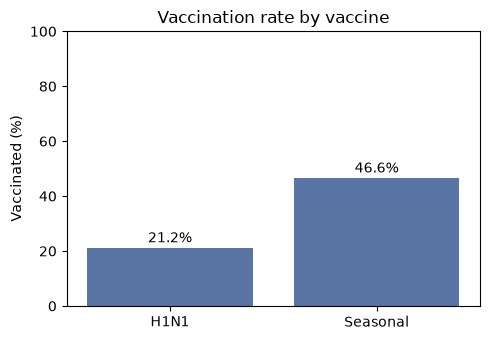

In [13]:
rates = (cleaned_train_data_df[TARGETS].mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=["H1N1", "Seasonal"], y=rates.values, ax=ax, color="#4C72B0")
ax.set_ylabel("Vaccinated (%)")
ax.set_ylim(0, 100)
ax.set_title("Vaccination rate by vaccine")
for i, v in enumerate(rates.values):
    ax.text(i, v + 2, f"{v}%", ha="center")
plt.tight_layout()
plt.show()

**Finding (H1N1 uptake is low, seasonal is near 50/50):** 21.2% of respondents got the H1N1 vaccine and 46.6% got the seasonal vaccine. H1N1 is imbalanced (79/21), so accuracy is a misleading metric later; use ROC AUC, as the competition does.

**Finding (H5 supported):** people who got the seasonal vaccine were about 5.5 times more likely to also get H1N1 (37.8% vs 6.8%). The correlation is 0.38, so moderate, not overwhelming. Going the other way, 82.8% of H1N1-vaccinated people also got the seasonal shot.

In [14]:
joint = pd.crosstab(
    cleaned_train_data_df["h1n1_vaccine"],
    cleaned_train_data_df["seasonal_vaccine"],
    normalize=True,
).mul(100).round(1)
display(joint)

print("P(H1N1 | seasonal=0, 1):",
      cleaned_train_data_df.groupby("seasonal_vaccine")["h1n1_vaccine"].mean().mul(100).round(1).tolist())
print("Correlation:", cleaned_train_data_df[TARGETS].corr().iloc[0, 1].round(3))

seasonal_vaccine,0,1
h1n1_vaccine,,
0,49.8,29.0
1,3.7,17.6


P(H1N1 | seasonal=0, 1): [6.8, 37.8]
Correlation: 0.377


In [15]:
def rate_table(df, col, order=None):
    out = df.groupby(col)[TARGETS].mean().mul(100).round(1)
    out["n"] = df.groupby(col).size()
    return out.loc[order] if order else out


def plot_rates(df, col, order=None, title=None):
    t = rate_table(df, col, order).drop(columns="n").reset_index()
    t = t.melt(id_vars=col, var_name="vaccine", value_name="rate")
    t["vaccine"] = t["vaccine"].map({"h1n1_vaccine": "H1N1", "seasonal_vaccine": "Seasonal"})
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=t, x=col, y="rate", hue="vaccine", order=order, ax=ax)
    ax.set_ylabel("Vaccinated (%)")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.set_title(title or f"Vaccination rate by {col}")
    for c in ax.containers:
        ax.bar_label(c, fmt="%.0f", padding=2)
    plt.tight_layout()
    plt.show()

,h1n1_vaccine,seasonal_vaccine,n
age_group,,,
18 - 34 Years,19.0,28.5,5215
35 - 44 Years,19.8,36.3,3848
45 - 54 Years,19.5,40.1,5238
55 - 64 Years,24.3,51.1,5563
65+ Years,22.7,67.4,6843


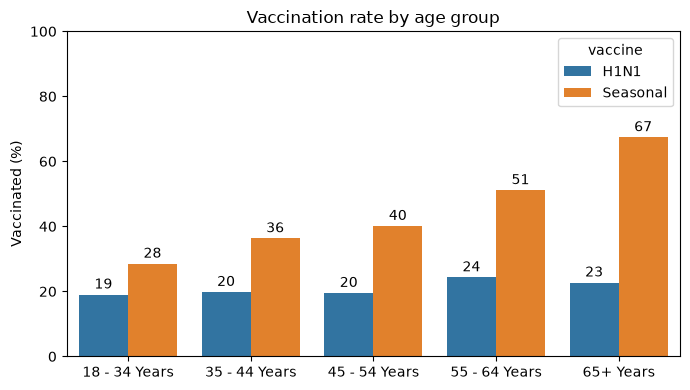

In [16]:
AGE_ORDER = sorted(
    cleaned_train_data_df["age_group"].unique(),
    key=lambda s: int(s.split()[0].replace("+", "")),
)

display(rate_table(cleaned_train_data_df, "age_group", AGE_ORDER))
plot_rates(cleaned_train_data_df, "age_group", AGE_ORDER, "Vaccination rate by age group")

**Finding (RQ1, H2 age part supported):** Seasonal uptake rises steadily with age, from 28.5% (18-34) to 67.4% (65+), a 39-point spread. H1N1 uptake is flat by comparison, ranging only 19.0-24.3%, and peaks at 55-64 rather than 65+. This supports the prediction that age matters much more for seasonal than for H1N1 vaccination.

*Caveat:* these are associations in survey data, not causes. Each group has at least 3,800 respondents, so the differences are not small-sample noise.

,h1n1_vaccine,seasonal_vaccine,n
education,,,
< 12 Years,16.7,40.1,2363
12 Years,18.5,44.8,5797
Some College,20.8,45.2,7043
College Graduate,24.6,51.1,10097
Unknown,18.6,38.5,1407


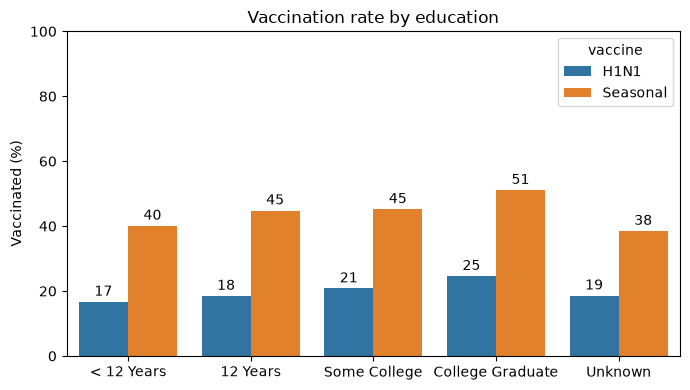

,h1n1_vaccine,seasonal_vaccine,n
income_poverty,,,
Below Poverty,19.1,36.3,2697
"<= $75,000, Above Poverty",20.3,47.7,12777
"> $75,000",25.3,49.7,6810
Unknown,18.9,44.8,4423


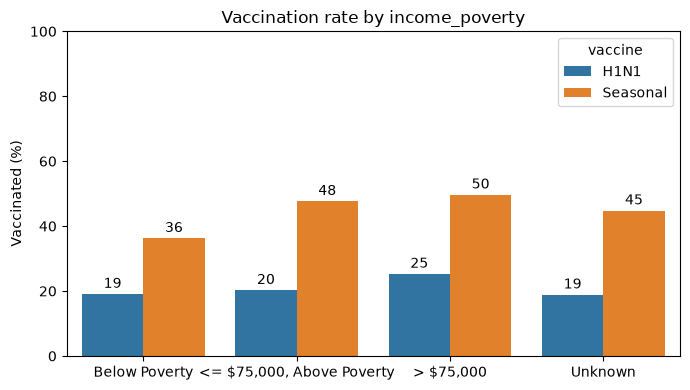

,h1n1_vaccine,seasonal_vaccine,n
sex,,,
Female,21.9,49.7,15858
Male,20.2,41.9,10849


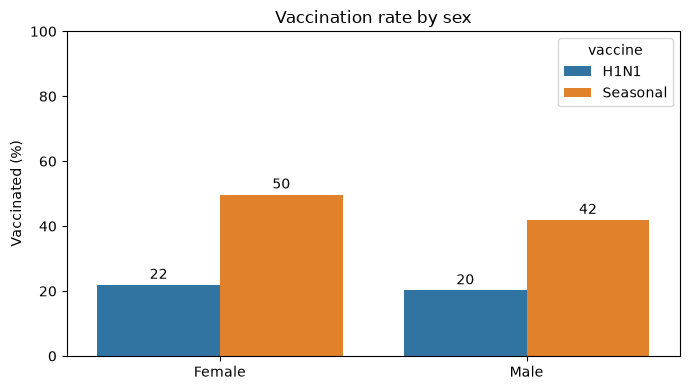

,h1n1_vaccine,seasonal_vaccine,n
race,,,
Black,14.9,35.0,2118
Hispanic,20.8,34.0,1755
Other or Multiple,21.7,42.0,1612
White,21.9,49.1,21222


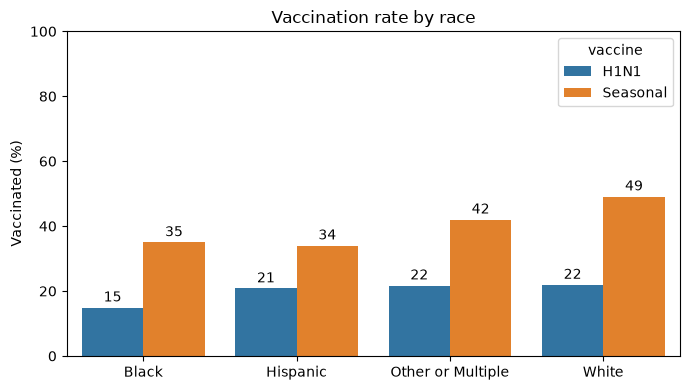

In [17]:
EDU_ORDER = ["< 12 Years", "12 Years", "Some College", "College Graduate", "Unknown"]
INC_ORDER = ["Below Poverty", "<= $75,000, Above Poverty", "> $75,000", "Unknown"]

for col, order in [
    ("education", EDU_ORDER),
    ("income_poverty", INC_ORDER),
    ("sex", None),
    ("race", None),
]:
    display(rate_table(cleaned_train_data_df, col, order))
    plot_rates(cleaned_train_data_df, col, order)

**Findings (H2, RQ2):**
- **Education:** uptake rises with each step for both vaccines (H1N1 16.7% to 24.6%, seasonal 40.1% to 51.1%).
- **Income:** the largest jump is between below-poverty and above-poverty for seasonal (36.3% to 47.7%); for H1N1 it is between ≤$75k and >$75k (20.3% to 25.3%).
- **Sex:** women vaccinate more for seasonal (49.7% vs 41.9%), but the H1N1 difference is small (21.9% vs 20.2%).
- **Race:** the seasonal rate is lowest for Hispanic (34.0%) and Black (35.0%) respondents versus White respondents (49.1%). H1N1 is lowest for Black respondents (14.9%).

*Caveat:* these are single-variable comparisons. Age, income, and education overlap, so part of each gap may reflect the others. Separating them needs a model, which comes in Sprint 2. The survey data alone can't say why the gaps exist.

,vaccine,doctor recommendation,vaccinated %
0,H1N1,No,13.6
1,H1N1,Yes,53.2
2,Seasonal,No,34.6
3,Seasonal,Yes,73.8


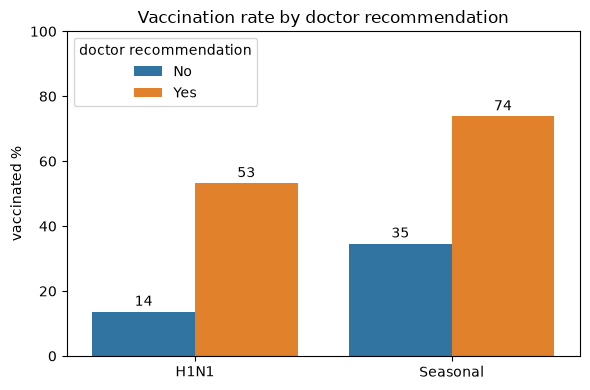

In [18]:
df = cleaned_train_data_df
PAIRS = {
    "H1N1": ("doctor_recc_h1n1", "h1n1_vaccine"),
    "Seasonal": ("doctor_recc_seasonal", "seasonal_vaccine"),
}

rows = []
for name, (rec, tgt) in PAIRS.items():
    rate = df.dropna(subset=[rec]).groupby(rec)[tgt].mean().mul(100).round(1)
    rows += [
        {"vaccine": name, "doctor recommendation": "No", "vaccinated %": rate[0.0]},
        {"vaccine": name, "doctor recommendation": "Yes", "vaccinated %": rate[1.0]},
    ]
recc = pd.DataFrame(rows)
display(recc)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=recc, x="vaccine", y="vaccinated %", hue="doctor recommendation", ax=ax)
ax.set_ylim(0, 100)
ax.set_xlabel("")
ax.set_title("Vaccination rate by doctor recommendation")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=2)
plt.tight_layout()
plt.show()

In [19]:
by_age = (
    df.dropna(subset=["doctor_recc_seasonal"])
    .pivot_table(index="age_group", columns="doctor_recc_seasonal",
                 values="seasonal_vaccine", aggfunc="mean")
    .mul(100).round(1).loc[AGE_ORDER]
    .rename(columns={0.0: "No recommendation", 1.0: "Recommended"})
)
by_age["gap (points)"] = (by_age["Recommended"] - by_age["No recommendation"]).round(1)
by_age

doctor_recc_seasonal,No recommendation,Recommended,gap (points)
age_group,,,
18 - 34 Years,20.3,57.5,37.2
35 - 44 Years,26.7,64.5,37.8
45 - 54 Years,30.5,69.3,38.8
55 - 64 Years,40.0,74.4,34.4
65+ Years,55.0,85.6,30.6


**Finding (H4 strongly supported):** Respondents whose doctor recommended the vaccine were far more likely to get it: H1N1 53.2% vs 13.6% (about 4 times higher), seasonal 73.8% vs 34.6% (about 2 times higher). The gap persists inside every age group (31-39 points for seasonal), so it is not just an age effect.

*Caveat:* an association, not proof of causation. Doctors may recommend the vaccine to people who were already inclined to get it. Doctor recommendation is also missing for 8.1% of respondents, who had the lowest H1N1 uptake (8.6%), which is why `doctor_recc_missing` was kept as a feature.

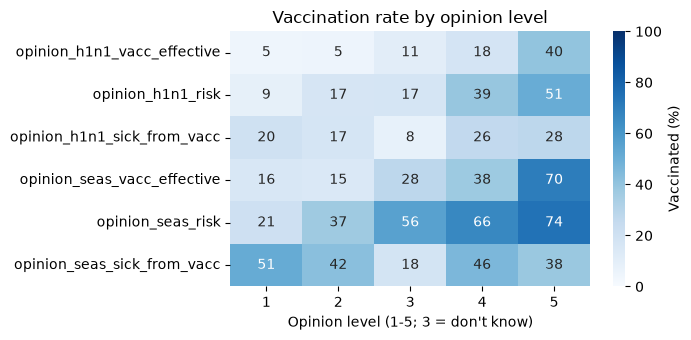

In [20]:
OPINIONS = {
    "opinion_h1n1_vacc_effective": "h1n1_vaccine",
    "opinion_h1n1_risk": "h1n1_vaccine",
    "opinion_h1n1_sick_from_vacc": "h1n1_vaccine",
    "opinion_seas_vacc_effective": "seasonal_vaccine",
    "opinion_seas_risk": "seasonal_vaccine",
    "opinion_seas_sick_from_vacc": "seasonal_vaccine",
}

belief_rates = pd.DataFrame({
    col: cleaned_train_data_df.groupby(col)[tgt].mean().mul(100).round(1)
    for col, tgt in OPINIONS.items()
}).T
belief_rates.columns = [int(c) for c in belief_rates.columns]

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(belief_rates, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "Vaccinated (%)"}, ax=ax)
ax.set_xlabel("Opinion level (1-5; 3 = don't know)")
ax.set_title("Vaccination rate by opinion level")
plt.tight_layout()
plt.show()

**Findings (H1 partly supported):**
- **Effectiveness and risk perception are strong, steady signals.** The more effective people think the vaccine is, and the more at risk they feel, the more they vaccinate (H1N1 effectiveness: 4.7% at level 1 to 40.5% at level 5; seasonal risk: 20.9% to 74.5%).
- **Fear of side effects does NOT behave as predicted.** For H1N1, people who were *more* worried about getting sick from the vaccine vaccinated slightly *more* (20.5% at level 1, 28.0% at level 5). For seasonal, uptake falls only mildly (51.3% to 38.5%). The relationship is not a smooth line.
- **Level 3 ("don't know") is small for risk and side-effects (94-1,117 respondents) but large for H1N1 effectiveness (4,723).** Treat it with care.

*Implication for modeling:* the side-effect questions are non-monotonic, so a model that treats them as a straight line would miss the pattern. Tree models handle this; for logistic regression, one-hot encode them.

In [21]:
BEHAVIORS = [c for c in cleaned_train_data_df.columns if c.startswith("behavioral_")]
HEALTH = ["chronic_med_condition", "health_worker", "child_under_6_months"]


def yes_no_gap(df, cols):
    rows = []
    for col in cols:
        d = df.dropna(subset=[col])
        g = d.groupby(col)[TARGETS].mean().mul(100)
        rows.append({
            "variable": col,
            "% answering yes": round((d[col] == 1).mean() * 100, 1),
            "h1n1 gap": round(g.loc[1.0, "h1n1_vaccine"] - g.loc[0.0, "h1n1_vaccine"], 1),
            "seasonal gap": round(g.loc[1.0, "seasonal_vaccine"] - g.loc[0.0, "seasonal_vaccine"], 1),
        })
    return pd.DataFrame(rows).set_index("variable")


yes_no_gap(cleaned_train_data_df, BEHAVIORS + HEALTH)

,% answering yes,h1n1 gap,seasonal gap
variable,,,
behavioral_antiviral_meds,4.9,7.7,1.5
behavioral_avoidance,72.6,4.4,8.5
behavioral_face_mask,6.9,11.4,9.9
behavioral_wash_hands,82.6,8.1,14.8
behavioral_large_gatherings,35.9,1.5,6.7
behavioral_outside_home,33.7,1.9,5.6
behavioral_touch_face,67.7,6.3,12.8
chronic_med_condition,28.3,8.7,18.8
health_worker,11.2,22.1,20.2


In [22]:
BEHAVIORS_DF = cleaned_train_data_df.assign(
    prevention_score=cleaned_train_data_df[BEHAVIORS].fillna(0).sum(axis=1).astype(int)
)
score_rates = BEHAVIORS_DF.groupby("prevention_score")[TARGETS].mean().mul(100).round(1)
score_rates["n"] = BEHAVIORS_DF.groupby("prevention_score").size()
score_rates

,h1n1_vaccine,seasonal_vaccine,n
prevention_score,,,
0,12.0,29.3,2109
1,16.3,37.1,2715
2,20.7,43.6,4584
3,22.8,49.6,7256
4,22.7,51.2,4331
5,23.1,52.4,4504
6,28.4,53.4,1037
7,33.3,47.4,171


**Findings (H3, RQ6 supported):** All seven preventive behaviors go with higher uptake of both vaccines. The strongest for seasonal are hand-washing (+14.7 points) and avoiding touching the face (+12.8); for H1N1, wearing a face mask (+11.3). A summed prevention score tracks uptake: seasonal 29.3% at score 0 versus 53.4% at score 6.

**Findings (RQ3 supported):** Health workers have the largest gaps (H1N1 +22.0, seasonal +20.1). A chronic condition matters much more for seasonal (+18.9) than for H1N1 (+8.6). Close contact with a child under 6 months matters for H1N1 (+10.0) but hardly for seasonal (+2.2).

*Caveat:* associations only. People who take one precaution tend to take others, and age is mixed in, so no single behavior should be read as the cause.

In [23]:
display(rate_table(cleaned_train_data_df, "employment_status"))

ranges = (
    cleaned_train_features_df.select_dtypes("number")
    .drop(columns=["respondent_id", "n_missing", "doctor_recc_missing"])
    .agg(["min", "max"]).T
)
display(ranges)

for col in ["employment_industry", "employment_occupation", "hhs_geo_region"]:
    vc = cleaned_train_features_df[col].value_counts()
    print(f"{col}: {len(vc)} levels, {(vc < 500).sum()} with under 500 respondents")

,h1n1_vaccine,seasonal_vaccine,n
employment_status,,,
Employed,21.6,42.2,13560
Not in Labor Force,21.9,55.8,10231
Unemployed,16.3,30.2,1453
Unknown,18.5,38.8,1463


,min,max
h1n1_concern,0.0,3.0
h1n1_knowledge,0.0,2.0
behavioral_antiviral_meds,0.0,1.0
behavioral_avoidance,0.0,1.0
behavioral_face_mask,0.0,1.0
behavioral_wash_hands,0.0,1.0
behavioral_large_gatherings,0.0,1.0
behavioral_outside_home,0.0,1.0
behavioral_touch_face,0.0,1.0
doctor_recc_h1n1,0.0,1.0


employment_industry: 23 levels, 10 with under 500 respondents
employment_occupation: 25 levels, 16 with under 500 respondents
hhs_geo_region: 10 levels, 0 with under 500 respondents


**Outliers:** none. All numeric columns are survey codes within their documented ranges (household counts are capped at 3 by design).

**High-cardinality columns:** industry and occupation have many sparse levels, but they are informative: seasonal uptake varies from about 20% to 85% across levels. Decision: do not hand-group in Sprint 1. In Sprint 2, group rare levels inside the modeling pipeline with `OneHotEncoder(min_frequency=500, handle_unknown="infrequent_if_exist")`, which learns the grouping from training data only and avoids leakage.

In [24]:
OUT_DIR = Path("../data_processed")
OUT_DIR.mkdir(exist_ok=True)

cleaned_train_data_df.to_csv(OUT_DIR / "train_clean.csv", index=False)
clean_features(test_features_df).to_csv(OUT_DIR / "test_clean.csv", index=False)